# Wavelength | Music Mood/Genre Classifier with Model Comparison


## Problem
We built a classification model that predicts a song’s genre or mood using Spotify audio features. The core problem is learning how combinations of audio features correspond to genre or mood labels. This is a supervised multiclass classification task, where the input is a set of numerical features and the output is a categorical label.

## Importance
Music genre classification powers applications like Spotify or Apple music for playlist generation, content recommendation, and music discovery. The output of the model could also provide insights on acoustic similarities between genres rather than just being a simple misclassification.

## Approach and methodology
Our approach includes feature engineering and basic feature selection, followed by training and comparing k-NN, Decision Tree, Random Forest, and Logistic Regression models. We will implement the pipeline in Python using Pandas, NumPy, and scikit-learn, with Matplotlib and Seaborn for visualizations. Model performance will be evaluated using F1 score, confusion matrices, and learning curve plots.

## Outcome
This project will develop a model that predicts a song’s genre or mood in real time using Spotify audio features. We will compare multiple classification models, analyze which audio features matter most, and evaluate the impact of normalization and hyperparameter tuning. The goal is to build a reproducible machine learning pipeline.

**Dataset**: [Link to Kaggle](https://www.kaggle.com/datasets/maharshipandya/-spotify-tracks-dataset/data)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score, ConfusionMatrixDisplay
)
import warnings
warnings.filterwarnings('ignore')

DATA_PATH = "dataset.csv"
TOP_N_GENRES = 10
# for splitting train and test
TEST_SIZE = 0.2
RANDOM_STATE = 0

DROP_COLS = ["Unnamed: 0", "artists", "album_name", "track_name",
             "explicit", "popularity", "duration_ms", "loudness"]

AUDIO_FEATURES = [
    "danceability", "energy", "speechiness",
    "acousticness", "instrumentalness", "liveness", "valence",
    "tempo", "time_signature", "key", "mode",
    # engineered
    "duration_min",
    "loudness_perceived",
    "energy_dance",
    "acoustic_instrumental",
]

## Pre-Processing

In [2]:
df_before = pd.read_csv('dataset.csv')

# before cleaning
print("Shape:\n", df_before.shape)
print("Dtypes:\n", df_before.dtypes)
print("Samples:\n", df_before.head)

# check any missing values
print("missing before:\n", df_before.isna().sum())
print("missing percent before:\n", (df_before.isna().sum() / len(df_before)) * 100)

# Drop nulls/ duplicates/ unnecessary columns
df = df_before.dropna().drop_duplicates(subset=["track_id"])
df = df.drop(columns=["Unnamed: 0", "artists", "album_name", "track_name", "explicit", "popularity"])

# print what is missing after
print("missing after:\n", df.isna().sum())
print("missing percent after:\n", (df.isna().sum() / len(df)) * 100)

# show data after cleaning
print("Shape:\n", df.shape)
print("Dtype:\n", df.dtypes)
print("Samples:\n", df.head())

Shape:
 (114000, 21)
Dtypes:
 Unnamed: 0            int64
track_id             object
artists              object
album_name           object
track_name           object
popularity            int64
duration_ms           int64
explicit               bool
danceability        float64
energy              float64
key                   int64
loudness            float64
mode                  int64
speechiness         float64
acousticness        float64
instrumentalness    float64
liveness            float64
valence             float64
tempo               float64
time_signature        int64
track_genre          object
dtype: object
Samples:
 <bound method NDFrame.head of         Unnamed: 0                track_id                 artists  \
0                0  5SuOikwiRyPMVoIQDJUgSV             Gen Hoshino   
1                1  4qPNDBW1i3p13qLCt0Ki3A            Ben Woodward   
2                2  1iJBSr7s7jYXzM8EGcbK5b  Ingrid Michaelson;ZAYN   
3                3  6lfxq3CG4xtTiEg7opyCyx      

## Feature Engineering

In [3]:
# Duration: ms to minutes
df["duration_min"] = df["duration_ms"] / 60000

# Loudness: dB to perceived loudness (0–1 scale)
df["loudness_perceived"] = 10 ** (df["loudness"] / 20)

# Interaction features
# high energy and high dance = high chance of EDM/ pop
df["energy_dance"] = df["energy"] * df["danceability"]
# high acoust and high instrumentalness = high chance of classical/ folk
df["acoustic_instrumental"] = df["acousticness"] * df["instrumentalness"]

# Preview
print("New features added:")
df[["duration_min", "loudness_perceived", "energy_dance",
    "acoustic_instrumental"]].describe()

New features added:


,duration_min,loudness_perceived,energy_dance,acoustic_instrumental
count,89740.000000,89740.000000,89740.000000,89740.000000
mean,3.819073,0.428686,0.363196,0.067456
std,1.882430,0.178986,0.179915,0.206603
min,0.143100,0.003338,0.000000,0.000000
25%,2.884000,0.304711,0.230202,0.000000
50%,3.554925,0.437270,0.375907,0.000003
75%,4.404883,0.555392,0.497640,0.001014
max,87.288250,1.685000,0.956480,0.995004


### Reasons for Decisions

Four new features were engineered to improve model performance and interpretability.

**Duration (ms to minutes):** `duration_ms` column was converted to minutes
by dividing by 60,000. This is a unit conversion for interpretability as values like 200,000ms are harder to interpret than 3.3 minutes.

**Perceived Loudness:** Loudness in dB is a logarithmic scale, meaning -6dB is not simply "twice as quiet" as -3dB. Converting using `10^(dB/20)` maps loudness to a linear 0–1 scale that better reflects how humans actually perceive volume differences between songs.

**Energy x Danceability:** A song can be high energy but not danceable (e.g. metal) or highly danceable but low energy (e.g. slow R&B). Multiplying the two produces a value that is high only when both are high, which strongly signals genres like EDM and pop. This gives the model a pre-computed signal it would otherwise have to learn implicitly.

**Acousticness x Instrumentalness:** Acousticness measures whether a song uses real instruments, and instrumentalness measures whether it has no vocals. A song that scores high on both (real instruments AND no singing) almost always turns out to be classical or acoustic jazz. Multiplying them creates a single feature that captures that combination directly.

In [4]:
top_genres = df["track_genre"].value_counts().nlargest(TOP_N_GENRES).index.tolist()
df = df[df["track_genre"].isin(top_genres)].copy()

print(f"Keeping top {TOP_N_GENRES} genres: {top_genres}")
print(f"Final dataset shape: {df.shape}")
print("\nClass distribution:")
print(df["track_genre"].value_counts())

Keeping top 10 genres: ['acoustic', 'afrobeat', 'alt-rock', 'ambient', 'cantopop', 'tango', 'chicago-house', 'forro', 'bluegrass', 'study']
Final dataset shape: (9987, 19)

Class distribution:
track_genre
acoustic         1000
afrobeat          999
alt-rock          999
ambient           999
cantopop          999
tango             999
bluegrass         998
chicago-house     998
forro             998
study             998
Name: count, dtype: int64


## EDA

Available genres: ['acoustic', 'afrobeat', 'alt-rock', 'ambient', 'bluegrass', 'cantopop', 'chicago-house', 'forro', 'study', 'tango']


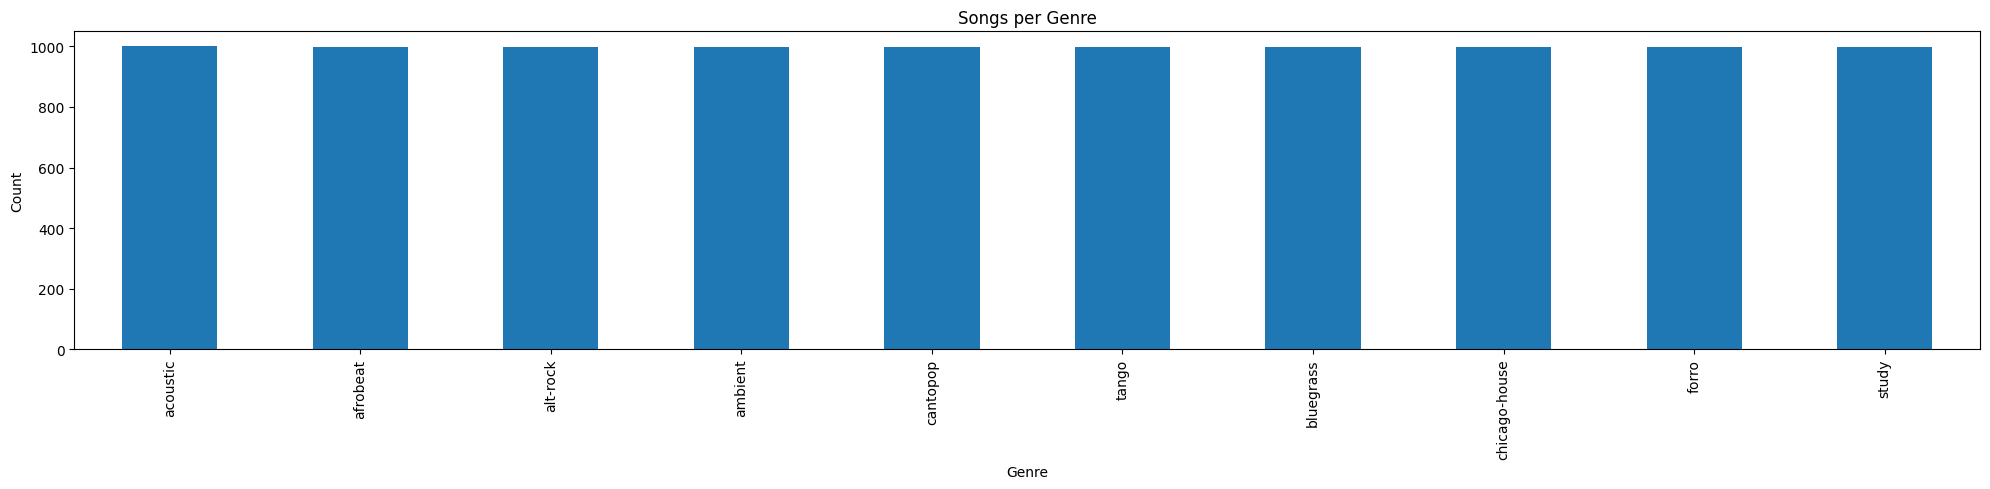

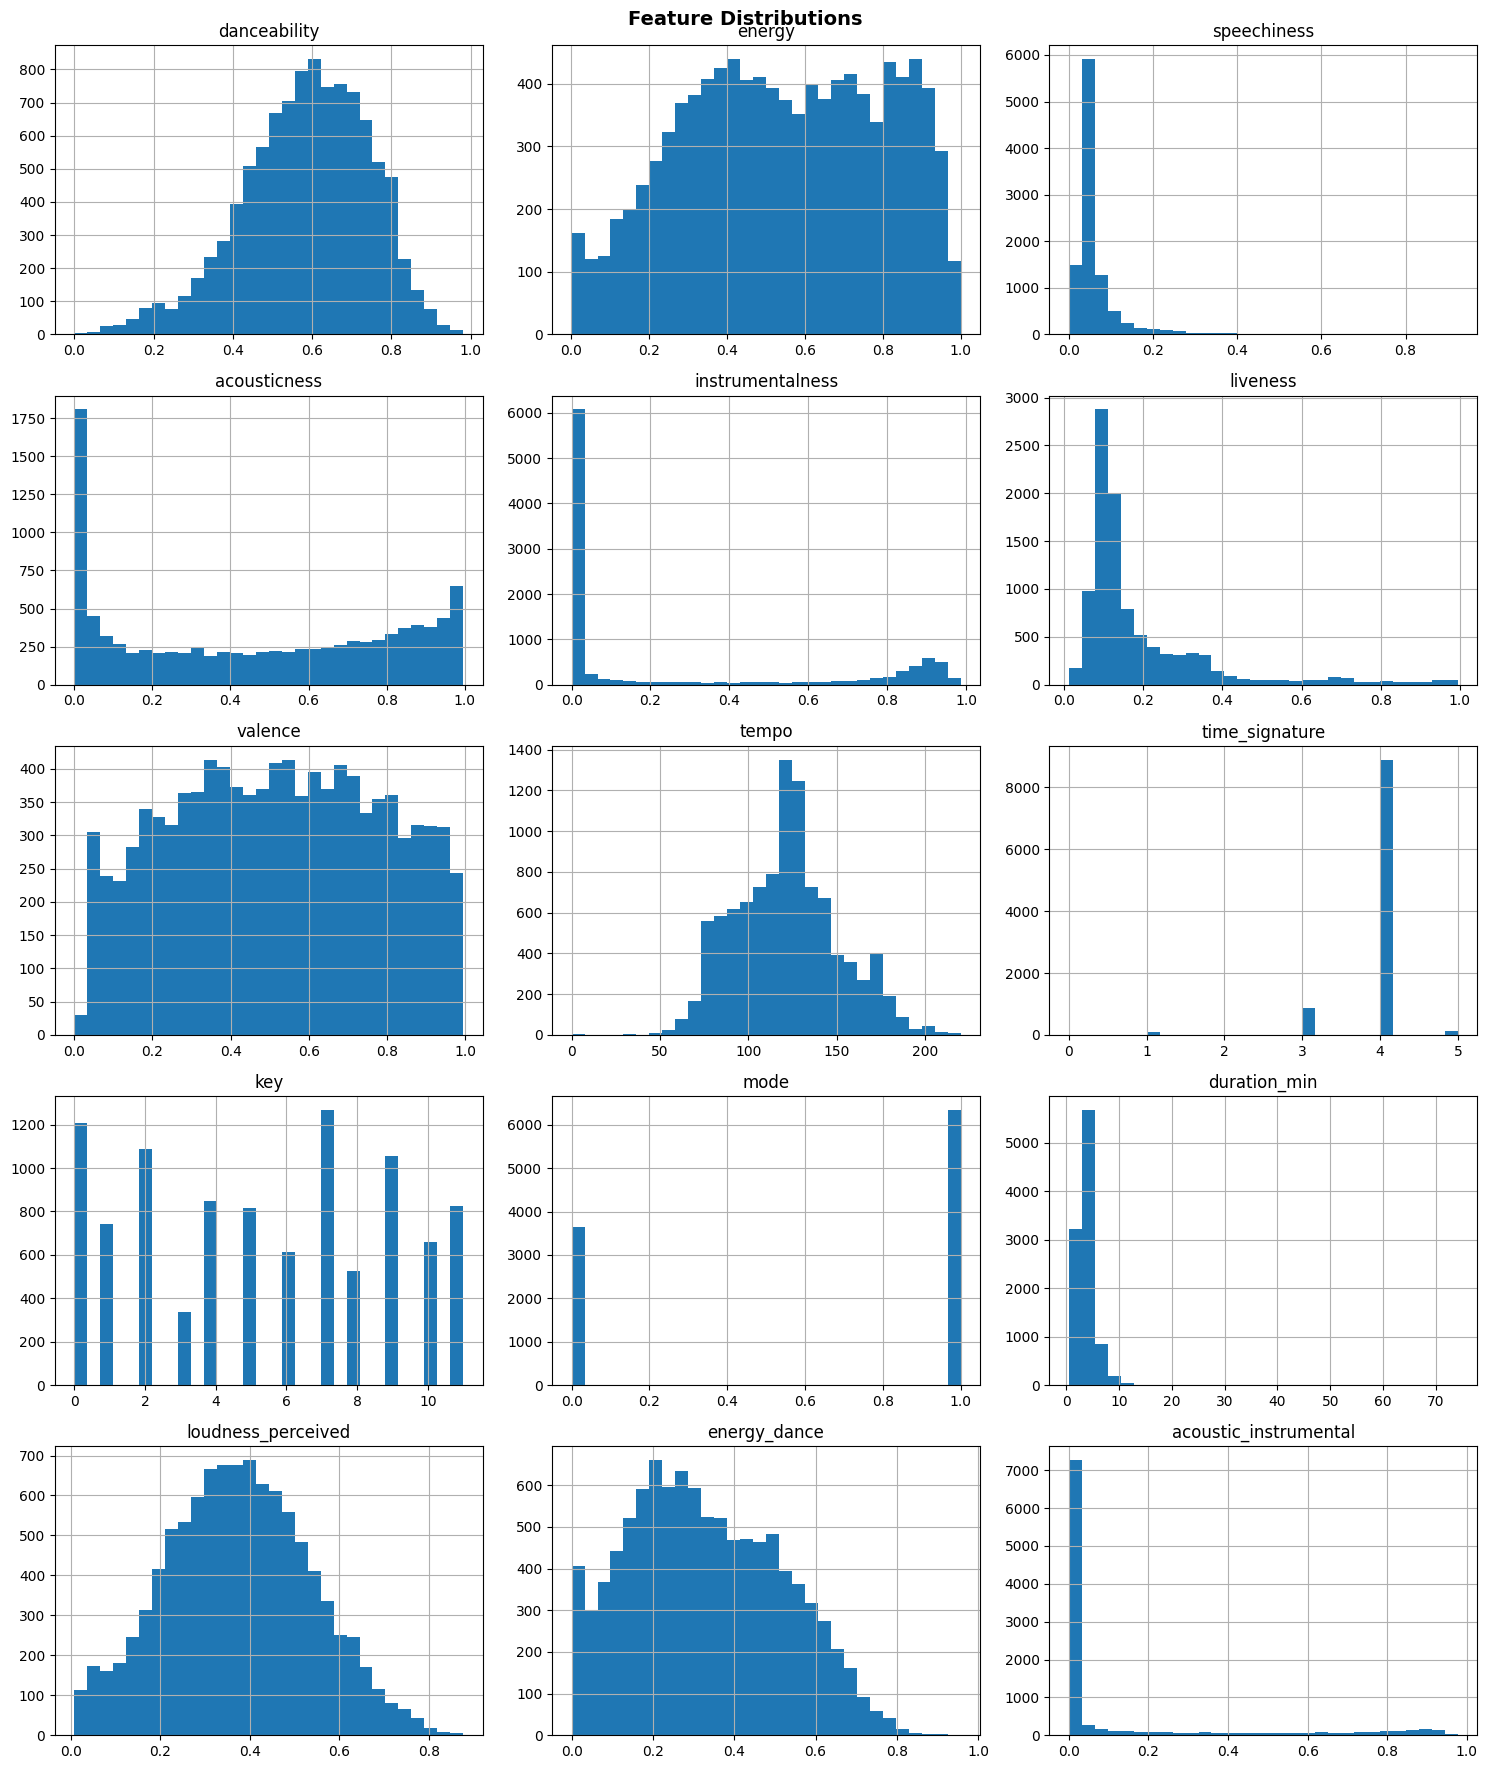

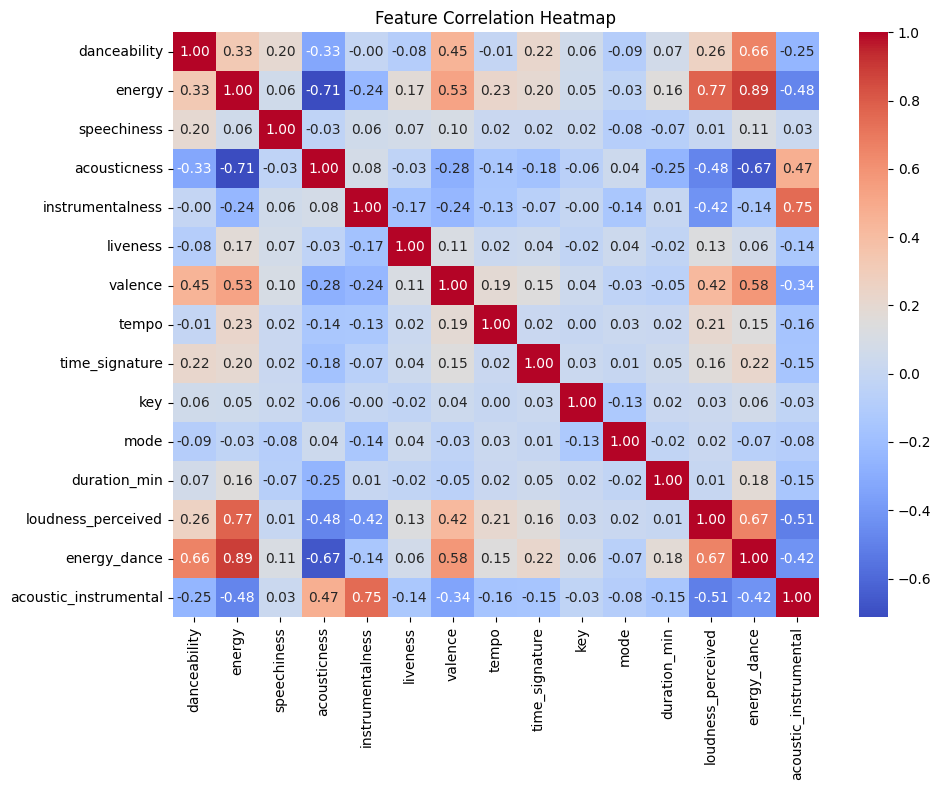

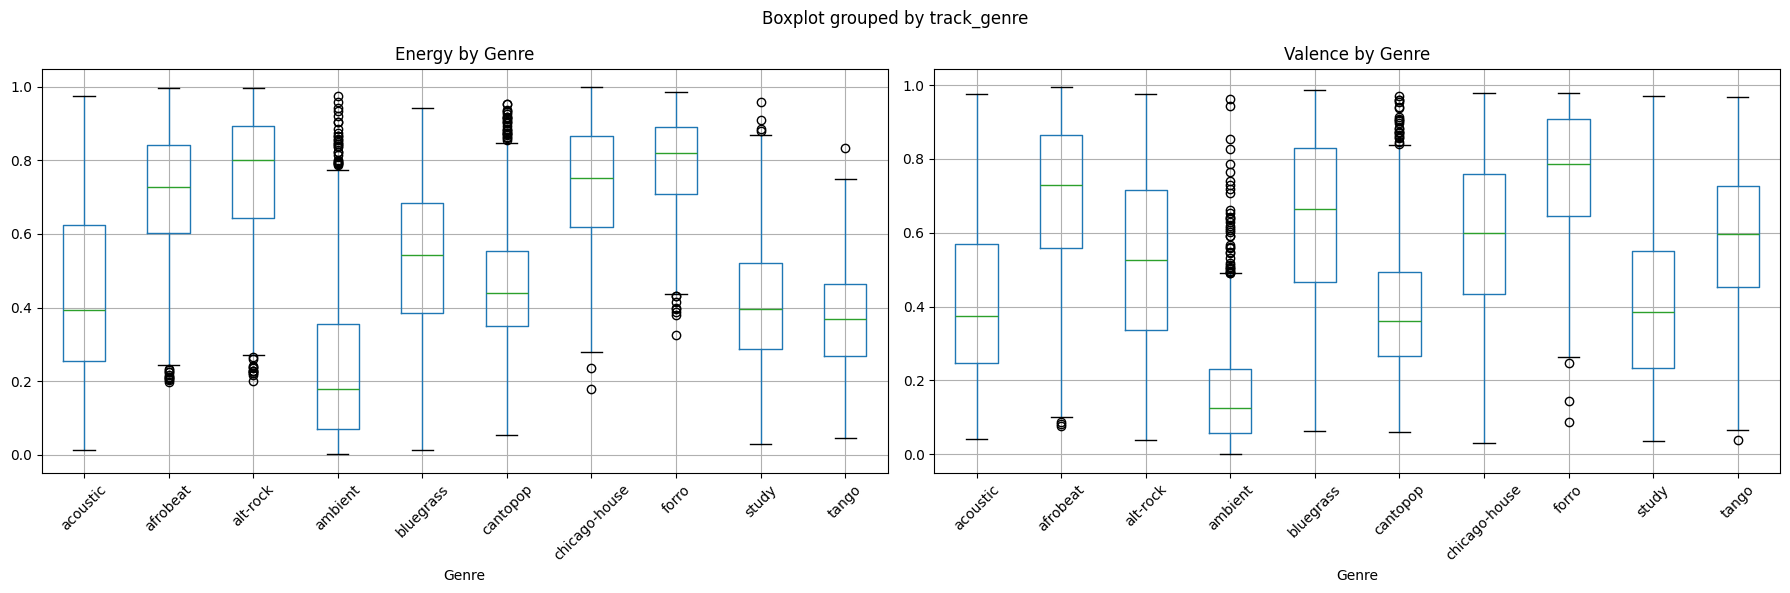

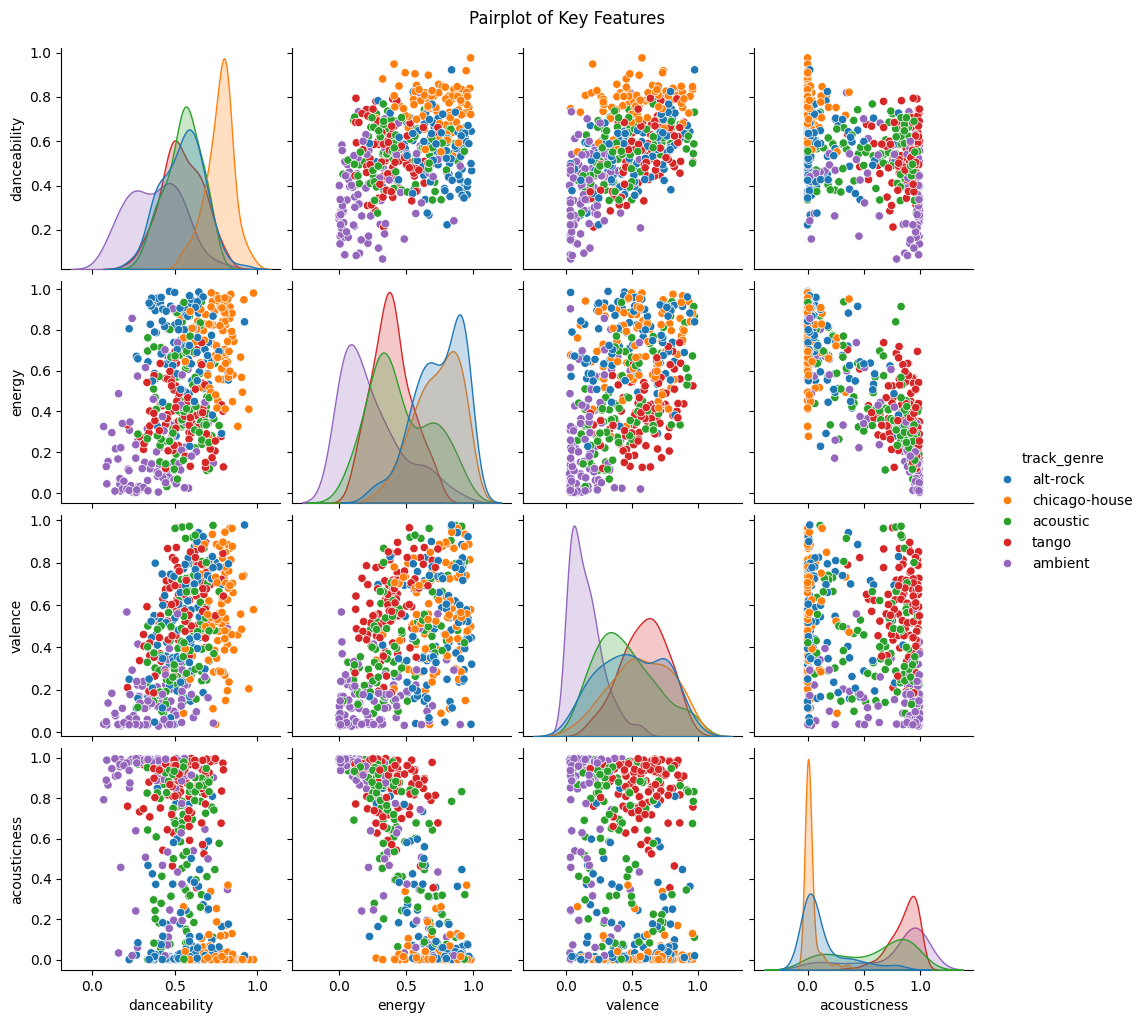

In [5]:
y = df["track_genre"]
print("Available genres:", sorted(y.unique()))

# 1. Class distribution (how many songs per genre)
plt.figure(figsize=(20, 5))
y.value_counts().plot(kind='bar')
plt.title('Songs per Genre')
plt.xlabel('Genre')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

# 2. Feature distributions
fig, axes = plt.subplots(5, 3, figsize=(15, 18))
for i, feature in enumerate(AUDIO_FEATURES):
    ax = axes[i // 3, i % 3]
    df[feature].hist(bins=30, ax=ax)
    ax.set_title(feature)

for j in range(len(AUDIO_FEATURES), 15):
    axes[j // 3, j % 3].set_visible(False)

plt.suptitle('Feature Distributions', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# 3. Correlation heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(df[AUDIO_FEATURES].corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

# 4. Boxplots | energy and valence by genre (top 10 genres)
top10 = y.value_counts().head(10).index
df_top = df[df['track_genre'].isin(top10)]

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

df_top.boxplot(column='energy', by='track_genre', ax=axes[0])
axes[0].set_title('Energy by Genre')
axes[0].set_xlabel('Genre')
plt.sca(axes[0])
plt.xticks(rotation=45)

df_top.boxplot(column='valence', by='track_genre', ax=axes[1])
axes[1].set_title('Valence by Genre')
axes[1].set_xlabel('Genre')
plt.sca(axes[1])
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# 5. Pairplot of key features
sample_genres = ['acoustic', 'alt-rock', 'ambient', 'chicago-house', 'tango']
sample_genres = [g for g in sample_genres if g in y.values]
df_sample = df[df['track_genre'].isin(sample_genres)].sample(500, random_state=RANDOM_STATE)
sns.pairplot(
    df_sample[['danceability', 'energy', 'valence', 'acousticness', 'track_genre']],
    hue='track_genre'
)
plt.suptitle('Pairplot of Key Features', y=1.02)
plt.show()

### Analysis of EDA

The feature distributions show that most songs in the dataset are vocal, studio-recorded, and electrically produced, with speechiness, instrumentalness, and liveness all skewing near 0. Danceability peaks around 0.6, and 4/4 time dominates with roughly 8,000+ songs. The correlation heatmap reveals that energy ties closely to loudness (0.77), energy_dance (0.89), and valence (0.53), suggesting significant feature overlap that motivates using PCA to reduce redundancy before modeling. The boxplots confirm that energy and valence are strong genre separators, high-energy genres like afrobeat, alt-rock, and chicago-house contrast clearly with low-energy genres like ambient and study, while forro and bluegrass stand out as high-valence genres compared to the more neutral or negative ambient and alt-rock.

## Feature Normalization

In [6]:
X = df[AUDIO_FEATURES].values
y_raw = df["track_genre"].values

le = LabelEncoder()
y_enc = le.fit_transform(y_raw)
print("Classes:", list(le.classes_))

# split
X_train, X_test, y_train, y_test = train_test_split(
    X, y_enc, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y_enc
)

# fit on train and transform both
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"\nTrain size: {X_train_scaled.shape}")
print(f"Test size:  {X_test_scaled.shape}")
print(f"Feature range - min: {X_train_scaled.min():.3f}, max: {X_train_scaled.max():.3f}")

Classes: ['acoustic', 'afrobeat', 'alt-rock', 'ambient', 'bluegrass', 'cantopop', 'chicago-house', 'forro', 'study', 'tango']

Train size: (7989, 15)
Test size:  (1998, 15)
Feature range - min: 0.000, max: 1.000


## PCA

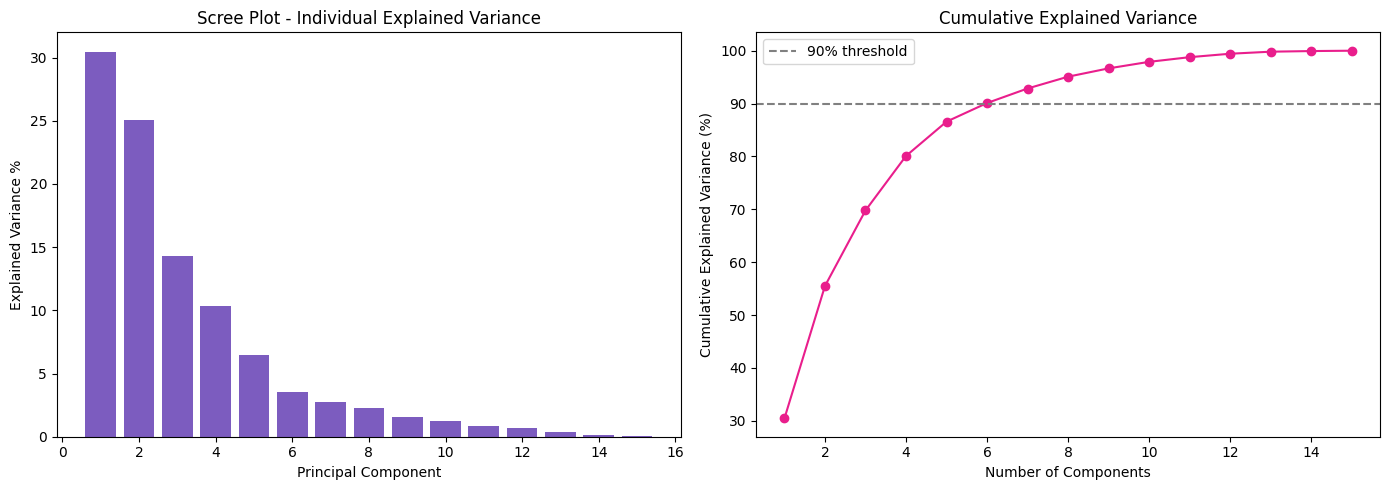

Components to explain 90% variance: 6
  PC1: 30.5%  (cumulative: 30.5%)
  PC2: 25.0%  (cumulative: 55.5%)
  PC3: 14.3%  (cumulative: 69.8%)
  PC4: 10.3%  (cumulative: 80.1%)
  PC5: 6.5%  (cumulative: 86.6%)
  PC6: 3.5%  (cumulative: 90.1%)
  PC7: 2.7%  (cumulative: 92.9%)
  PC8: 2.2%  (cumulative: 95.1%)
  PC9: 1.6%  (cumulative: 96.7%)
  PC10: 1.2%  (cumulative: 97.9%)
  PC11: 0.9%  (cumulative: 98.8%)
  PC12: 0.7%  (cumulative: 99.4%)
  PC13: 0.4%  (cumulative: 99.8%)
  PC14: 0.1%  (cumulative: 99.9%)
  PC15: 0.1%  (cumulative: 100.0%)


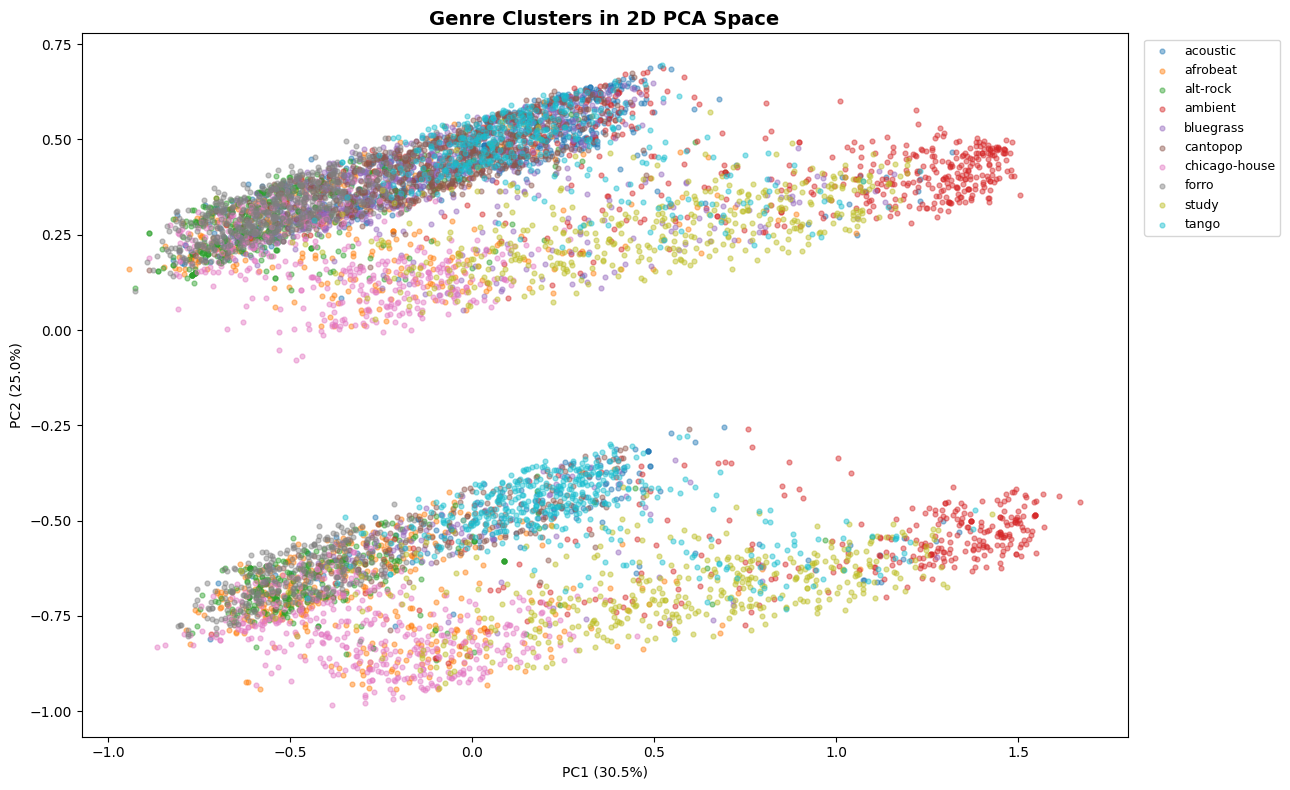

PCA output shape (n_components=6): (7989, 6)
PC1 top features:
danceability             PC6
energy                   PC1
speechiness              PC5
acousticness             PC5
instrumentalness         PC3
liveness                 PC6
valence                  PC5
tempo                    PC6
time_signature           PC1
key                      PC4
mode                     PC2
duration_min             PC5
loudness_perceived       PC6
energy_dance             PC1
acoustic_instrumental    PC1
dtype: object

PC loadings:
     danceability  energy  speechiness  acousticness  instrumentalness  \
PC1        -0.119  -0.384       -0.003         0.464             0.449   
PC2        -0.071  -0.102       -0.014         0.168            -0.190   
PC3         0.110   0.227        0.010        -0.468             0.719   
PC4         0.002  -0.031        0.002         0.021             0.020   
PC5         0.214   0.106        0.032         0.523             0.077   
PC6        -0.380   0.350     

In [7]:
n_components = len(AUDIO_FEATURES)
pca_full = PCA(n_components=n_components, random_state=RANDOM_STATE)
pca_full.fit(X_train_scaled)

explained_var = pca_full.explained_variance_ratio_
cumulative = np.cumsum(explained_var)

# plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].bar(range(1, n_components + 1), explained_var * 100, color="#7C5CBF")
axes[0].set_xlabel("Principal Component")
axes[0].set_ylabel("Explained Variance %")
axes[0].set_title("Scree Plot - Individual Explained Variance")
axes[1].plot(range(1, n_components + 1), cumulative * 100, marker="o", color="#E91E8C")
axes[1].axhline(y=90, color="gray", linestyle="--", label="90% threshold")
axes[1].set_xlabel("Number of Components")
axes[1].set_ylabel("Cumulative Explained Variance (%)")
axes[1].set_title("Cumulative Explained Variance")
axes[1].legend()
plt.tight_layout()
plt.show()

n_90 = int(np.argmax(cumulative >= 0.90)) + 1
print(f"Components to explain 90% variance: {n_90}")
for i, (ev, cum) in enumerate(zip(explained_var, cumulative)):
    print(f"  PC{i+1}: {ev*100:.1f}%  (cumulative: {cum*100:.1f}%)")

pca_2d = PCA(n_components=2, random_state=RANDOM_STATE)
X_train_2d = pca_2d.fit_transform(X_train_scaled)

# plot
fig, ax = plt.subplots(figsize=(13, 8))
palette = plt.cm.get_cmap("tab10", len(le.classes_))
for i, genre in enumerate(le.classes_):
    mask = y_train == i
    ax.scatter(X_train_2d[mask, 0], X_train_2d[mask, 1],
               label=genre, alpha=0.45, s=12, color=palette(i))

ax.set_xlabel(f"PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}%)")
ax.set_ylabel(f"PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}%)")
ax.set_title("Genre Clusters in 2D PCA Space", fontsize=14, fontweight="bold")
ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=9)
plt.tight_layout()
plt.show()

pca = PCA(n_components=n_90, random_state=RANDOM_STATE)
# new train and test
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print(f"PCA output shape (n_components={n_90}): {X_train_pca.shape}")

# added in for analysis purposes
print("PC1 top features:")
pc_df = pd.DataFrame(
    pca.components_,
    columns=AUDIO_FEATURES,
    index=[f"PC{i+1}" for i in range(pca.n_components_)]
)
print(pc_df.T.abs().idxmax(axis=1))
print("\nPC loadings:")
print(pc_df.round(3))

## PCA Analysis

PCA was applied to the 15 scaled features to reduce dimensionality before modeling. A 90%
explained variance threshold was used to determine the number of components to retain,
resulting in 6 components. The first two components alone account for 55.5% of the variance, with PC1 at 30.5% and PC2 at 25.0%, suggesting that a large portion of the information in the dataset is captured by just a few underlying patterns. Each additional component contributes diminishing returns, with PC6 adding only 3.5% to reach the 90.1% threshold. The remaining 9 components collectively explain less than 10% of the variance and were dropped to reduce noise and improve k-NN performance. The PCA output shape of (7,989, 6) confirms the training set was successfully reduced from 15 features to 6 components. The first principal component (PC1) captures 30.5% of the variance and essentially separates songs by whether they are quiet and acoustic or loud and energetic, with features like acousticness and instrumentalness pulling in one direction and energy and loudness pulling in the other. This is an intuitive split for genre classification, as genres like classical
and folk tend to be acoustic and quiet while genres like alt-rock and chicago-house tend to
be loud and energetic.

In [8]:
# eval helper for k-NN and Decision Tree
def evaluate_model(model, X_test, y_test, le, model_name):
  # gen preds and show mets
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    print(f"\n{model_name} — Test Accuracy: {acc:.4f} ({acc*100:.2f}%)")
    print(classification_report(y_test, y_pred, target_names=le.classes_))

    # plot
    cm = confusion_matrix(y_test, y_pred)
    fig, ax = plt.subplots(figsize=(12, 10))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
    disp.plot(ax=ax, colorbar=True, xticks_rotation=45)
    ax.set_title(f"{model_name} — Confusion Matrix", fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.show()

    return acc, y_pred

## k-NN

  k= 1  CV accuracy: 0.4739 +- 0.0079
  k= 2  CV accuracy: 0.4338 +- 0.0086
  k= 3  CV accuracy: 0.4862 +- 0.0089
  k= 4  CV accuracy: 0.4964 +- 0.0098
  k= 5  CV accuracy: 0.5064 +- 0.0062
  k= 6  CV accuracy: 0.5072 +- 0.0104
  k= 7  CV accuracy: 0.5161 +- 0.0093
  k= 8  CV accuracy: 0.5181 +- 0.0058
  k= 9  CV accuracy: 0.5152 +- 0.0091
  k=10  CV accuracy: 0.5168 +- 0.0064
  k=11  CV accuracy: 0.5188 +- 0.0103
  k=12  CV accuracy: 0.5202 +- 0.0079
  k=13  CV accuracy: 0.5262 +- 0.0075
  k=14  CV accuracy: 0.5252 +- 0.0094
  k=15  CV accuracy: 0.5236 +- 0.0062
  k=16  CV accuracy: 0.5247 +- 0.0062
  k=17  CV accuracy: 0.5280 +- 0.0070
  k=18  CV accuracy: 0.5272 +- 0.0066
  k=19  CV accuracy: 0.5263 +- 0.0075
  k=20  CV accuracy: 0.5304 +- 0.0078
  k=21  CV accuracy: 0.5289 +- 0.0075
  k=22  CV accuracy: 0.5297 +- 0.0094
  k=23  CV accuracy: 0.5319 +- 0.0094
  k=24  CV accuracy: 0.5290 +- 0.0092
  k=25  CV accuracy: 0.5307 +- 0.0079

Best k: 23 (CV acc: 0.5319)


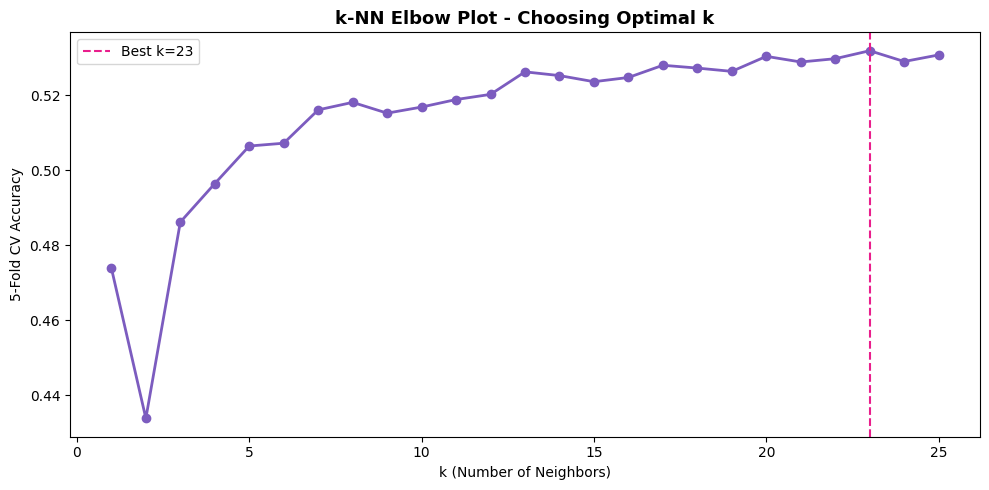

Fitting 5 folds for each of 18 candidates, totalling 90 fits
Best params: {'metric': 'manhattan', 'n_neighbors': 24, 'weights': 'distance'}
Best CV acc: 0.5541

k-NN — Test Accuracy: 0.5506 (55.06%)
               precision    recall  f1-score   support

     acoustic       0.37      0.31      0.34       200
     afrobeat       0.40      0.22      0.28       200
     alt-rock       0.47      0.66      0.55       200
      ambient       0.86      0.68      0.76       200
    bluegrass       0.42      0.31      0.36       200
     cantopop       0.45      0.56      0.50       200
chicago-house       0.63      0.71      0.67       200
        forro       0.58      0.70      0.63       199
        study       0.64      0.72      0.68       199
        tango       0.65      0.65      0.65       200

     accuracy                           0.55      1998
    macro avg       0.55      0.55      0.54      1998
 weighted avg       0.55      0.55      0.54      1998



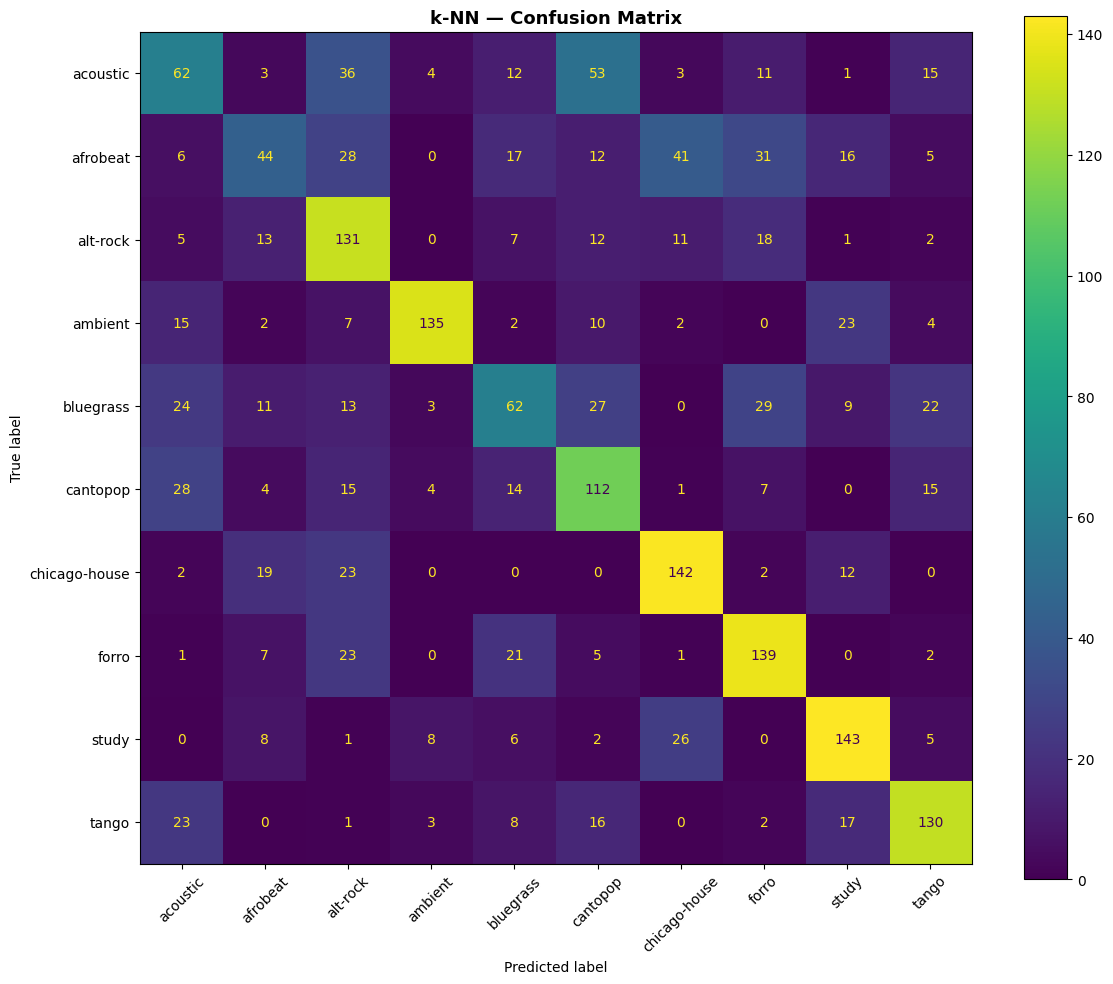

In [9]:
# elbow method
k_range = range(1, 26)
cv_scores = []

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k, metric="minkowski", p=2, n_jobs=-1)
    # uses pca x and y
    scores = cross_val_score(knn, X_train_pca, y_train, cv=5, scoring="accuracy")
    cv_scores.append(scores.mean())
    print(f"  k={k:2d}  CV accuracy: {scores.mean():.4f} +- {scores.std():.4f}")

best_k = list(k_range)[np.argmax(cv_scores)]
print(f"\nBest k: {best_k} (CV acc: {max(cv_scores):.4f})")

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(list(k_range), cv_scores, marker="o", color="#7C5CBF", linewidth=2)
ax.axvline(x=best_k, color="#E91E8C", linestyle="--", label=f"Best k={best_k}")
ax.set_xlabel("k (Number of Neighbors)")
ax.set_ylabel("5-Fold CV Accuracy")
ax.set_title("k-NN Elbow Plot - Choosing Optimal k", fontsize=13, fontweight="bold")
ax.legend()
plt.tight_layout()
plt.show()

# gridsearchCV
param_grid = {
    "n_neighbors": [best_k - 1, best_k, best_k + 1],
    "metric": ["minkowski", "euclidean", "manhattan"],
    "weights": ["uniform", "distance"]
}
grid_knn = GridSearchCV(
    KNeighborsClassifier(n_jobs=-1), param_grid,
    cv=5, scoring="accuracy", n_jobs=-1, verbose=1
)
grid_knn.fit(X_train_pca, y_train)

print(f"Best params: {grid_knn.best_params_}")
print(f"Best CV acc: {grid_knn.best_score_:.4f}")

# eval
knn_model = grid_knn.best_estimator_
knn_model.fit(X_train_pca, y_train)
knn_acc, knn_preds = evaluate_model(knn_model, X_test_pca, y_test, le, "k-NN")

## k - NN Results

## k-NN Analysis

The elbow plot shows accuracy steadily improving from k=1 (47.39%) through k=23 (53.19%), with no sharp drop-off suggesting the model benefits from considering more neighbors rather than just the closest one. The curve flattens out around k=13 onward, indicating diminishing returns beyond that point. GridSearchCV identified k=24 with manhattan distance and distance-weighted voting as the optimal configuration, improving cross-validation accuracy
to 55.41% and achieving a final test accuracy of 55.06%.

Looking at the per-genre results, ambient performed best with an F1 score of 0.76, likely because its audio profile (very low energy, highly instrumental) is distinct enough to separate it from most other genres. Study (0.68), chicago-house (0.67), and forro (0.63) also performed reasonably well. Acoustic and afrobeat struggled the most with F1 scores of 0.34 and 0.28, and the confusion matrix confirms this: acoustic was frequently
misclassified as cantopop (53 instances) and alt-rock (36 instances), suggesting these
genres share similar audio feature profiles. The overall confusion matrix is
largely blue with few standout values, indicating the model spreads its errors broadly across genres rather than making one systematic mistake.

## Decision Tree

Fitting 5 folds for each of 120 candidates, totalling 600 fits
Best params: {'criterion': 'gini', 'max_depth': 10, 'min_samples_leaf': 5, 'min_samples_split': 20}
Best CV acc: 0.6045

Decision Tree — Test Accuracy: 0.5921 (59.21%)
               precision    recall  f1-score   support

     acoustic       0.32      0.39      0.35       200
     afrobeat       0.41      0.47      0.43       200
     alt-rock       0.47      0.52      0.49       200
      ambient       0.76      0.69      0.72       200
    bluegrass       0.49      0.46      0.47       200
     cantopop       0.53      0.47      0.50       200
chicago-house       0.78      0.74      0.76       200
        forro       0.73      0.69      0.71       199
        study       0.86      0.87      0.87       199
        tango       0.68      0.63      0.66       200

     accuracy                           0.59      1998
    macro avg       0.60      0.59      0.60      1998
 weighted avg       0.60      0.59      0.60      19

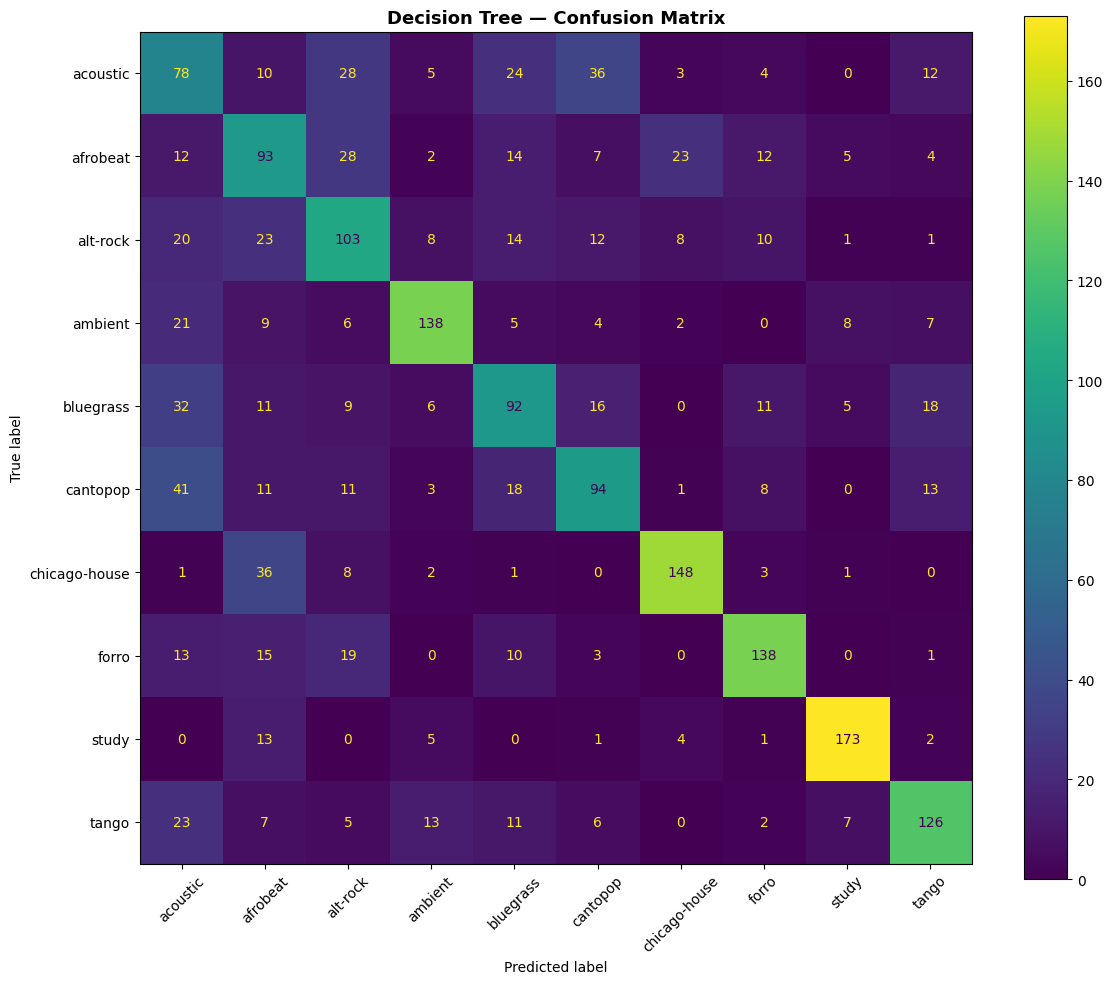

In [10]:
# gridsearchCV
param_grid = {
    "criterion": ["gini", "entropy"],
    "max_depth": [5, 10, 15, 20, None],
    "min_samples_split": [2, 5, 10, 20],
    "min_samples_leaf": [1, 2, 5]
}
grid_dt = GridSearchCV(
    DecisionTreeClassifier(random_state=RANDOM_STATE),
    param_grid, cv=5, scoring="accuracy", n_jobs=-1, verbose=1
)
grid_dt.fit(X_train_scaled, y_train)

print(f"Best params: {grid_dt.best_params_}")
print(f"Best CV acc: {grid_dt.best_score_:.4f}")

# eval
dt_model = grid_dt.best_estimator_
# notice, doesn't use pca x and y
dt_model.fit(X_train_scaled, y_train)
dt_acc, dt_preds = evaluate_model(dt_model, X_test_scaled, y_test, le, "Decision Tree")

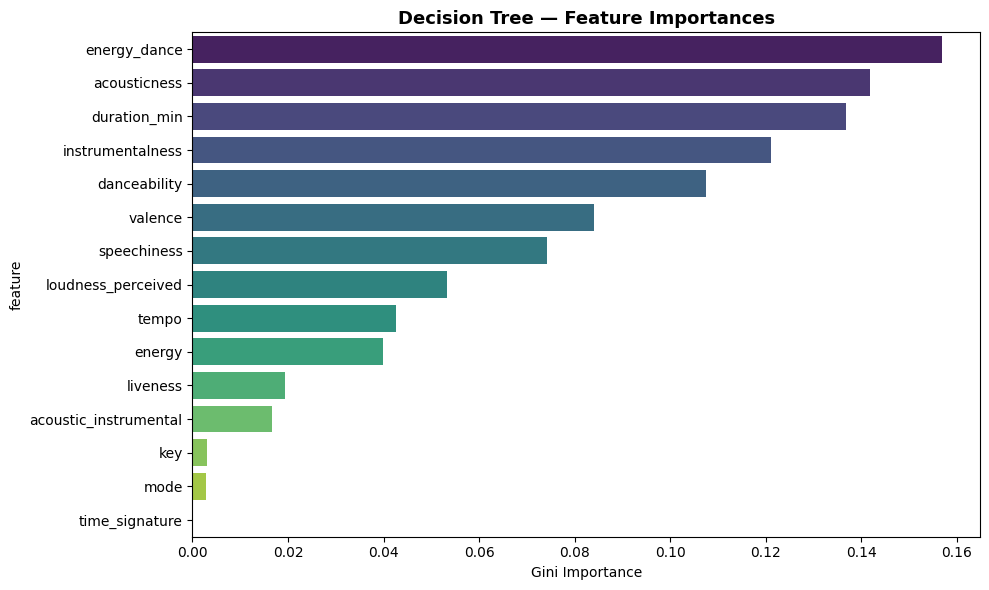

              feature  importance
         energy_dance    0.156967
         acousticness    0.141830
         duration_min    0.136869
     instrumentalness    0.121024
         danceability    0.107454
              valence    0.084124
          speechiness    0.074167
   loudness_perceived    0.053194
                tempo    0.042614
               energy    0.039816
             liveness    0.019321
acoustic_instrumental    0.016693
                  key    0.003019
                 mode    0.002908
       time_signature    0.000000


In [11]:
# feature importances plot
feat_df = pd.DataFrame({
    "feature": AUDIO_FEATURES,
    "importance": dt_model.feature_importances_
}).sort_values("importance", ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(data=feat_df, x="importance", y="feature", palette="viridis", ax=ax)
ax.set_title("Decision Tree — Feature Importances", fontsize=13, fontweight="bold")
ax.set_xlabel("Gini Importance")
plt.tight_layout()
plt.show()

print(feat_df.to_string(index=False))

## Decision Tree Analysis

GridSearchCV selected gini criterion with a max depth of 10, minimum samples per node of 5, and minimum samples per split of 20, achieving a cross-validation accuracy of 60.45% and a final test accuracy of 59.21% which outperforms k-NN by about 4%.

Study was the best with an F1 score of 0.87, likely because study music has
a very distinct audio profile (low energy, highly instrumental, and consistent tempo).
Chicago-house (0.76), ambient (0.72), and forro (0.71) also performed well, while acoustic struggled the most at 0.35, suggesting its audio features overlap significantly with other genres. Afrobeat improved notably compared to k-NN, going from 0.28 to 0.43.

The feature importance rankings reveal that the engineered features contributed meaningfully. Energy_dance was the single most important feature at 15.7%, followed by acousticness (14.2%) and duration_min (13.7%). Instrumentalness and danceability round out the top five. Notably, time_signature had zero importance, confirming it adds no signal for genre classification and could be dropped in future iterations. Mode and key also contributed very little at 0.29% and 0.30% respectively, while the acoustic_instrumental interaction feature underperformed relative to its individual components, suggesting the tree was able to learn that relationship on its own without needing the pre-computed interaction.

## Results

In [12]:
print("RESULTS SUMMARY")
print(f"  k-NN accuracy:          {knn_acc*100:.2f}%  (PCA-reduced, n_components={n_90})")
print(f"  Decision Tree accuracy: {dt_acc*100:.2f}%  (full scaled features)")

RESULTS SUMMARY
  k-NN accuracy:          55.06%  (PCA-reduced, n_components=6)
  Decision Tree accuracy: 59.21%  (full scaled features)


## k - NN vs. Decision Tree

The Decision Tree outperformed k-NN by approximately 4%, achieving 59.21%
compared to 55.06%. This gap is likely attributable to a few factors. First, the Decision Tree was trained on all 15 scaled features while k-NN was trained on 6 PCA-reduced components, some discriminative signal may have been lost in the dimensionality reduction.
Second, Decision Trees are better suited to this type of problem as they can learn non-linear boundaries by splitting on individual features, whereas k-NN relies purely on distance in feature space which becomes less reliable with overlapping genres. Both models performed strongest on genres with distinct audio profiles such as study, ambient, and chicago-house, and struggled most with acoustic and afrobeat, suggesting these genres are inherently harder to separate using Spotify audio features alone.

# Random Forest GridSearchCV

In [13]:
print("runtime works")

runtime works


In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

print("imports work")

imports work


In [15]:
df = pd.read_csv("dataset.csv")

df = df.dropna().drop_duplicates(subset=["track_id"]).copy()
df = df.drop(columns=["Unnamed: 0", "artists", "album_name", "track_name", "explicit", "popularity"])

df["duration_min"] = df["duration_ms"] / 60000.0
df["loudness_perceived"] = 10 ** (df["loudness"] / 20.0)
df["energy_dance"] = df["energy"] * df["danceability"]
df["acoustic_instrumental"] = df["acousticness"] * df["instrumentalness"]

top_genres = df["track_genre"].value_counts().nlargest(10).index.tolist()
df = df[df["track_genre"].isin(top_genres)].copy()

AUDIO_FEATURES = [
    "danceability", "energy", "speechiness",
    "acousticness", "instrumentalness", "liveness", "valence",
    "tempo", "time_signature", "key", "mode",
    "duration_min", "loudness_perceived",
    "energy_dance", "acoustic_instrumental"
]

X = df[AUDIO_FEATURES].values
y_raw = df["track_genre"].values

le = LabelEncoder()
y_enc = le.fit_transform(y_raw)

X_train, X_test, y_train, y_test = train_test_split(
    X, y_enc, test_size=0.2, random_state=0, stratify=y_enc
)

scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("data ready")
print(X_train_scaled.shape, X_test_scaled.shape)
print(list(le.classes_))

data ready
(7989, 15) (1998, 15)
['acoustic', 'afrobeat', 'alt-rock', 'ambient', 'bluegrass', 'cantopop', 'chicago-house', 'forro', 'study', 'tango']


starting random forest fit
Fitting 3 folds for each of 4 candidates, totalling 12 fits
[CV] END max_depth=None, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   1.0s
[CV] END max_depth=None, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   1.0s
[CV] END max_depth=None, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   1.2s
[CV] END max_depth=None, max_features=sqrt, min_samples_leaf=1, min_samples_split=5, n_estimators=100; total time=   1.4s
[CV] END max_depth=None, max_features=sqrt, min_samples_leaf=1, min_samples_split=5, n_estimators=100; total time=   1.0s
[CV] END max_depth=None, max_features=sqrt, min_samples_leaf=1, min_samples_split=5, n_estimators=100; total time=   0.9s
[CV] END max_depth=10, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   0.8s
[CV] END max_depth=10, max_features=sqrt, min_samples_leaf=1,

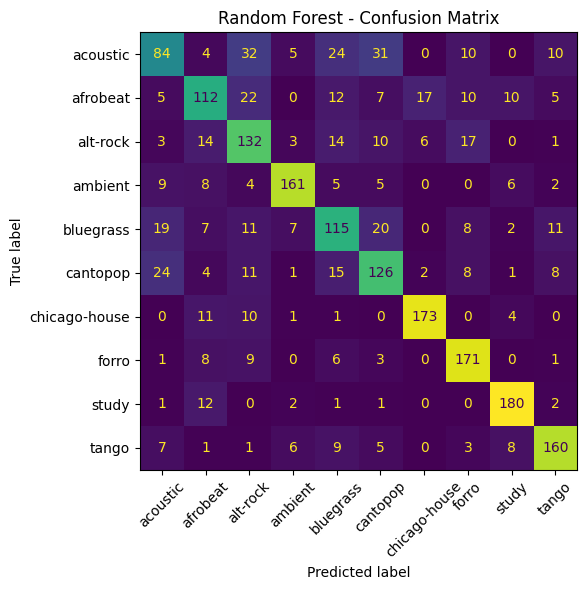

In [16]:
param_grid_rf = {
    "n_estimators": [100],
    "max_depth": [None, 10],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1],
    "max_features": ["sqrt"]
}

grid_rf = GridSearchCV(
    estimator=RandomForestClassifier(random_state=0, n_jobs=-1),
    param_grid=param_grid_rf,
    cv=3,
    scoring="accuracy",
    n_jobs=1,
    verbose=2
)

print("starting random forest fit")
grid_rf.fit(X_train_scaled, y_train)
print("fit finished")

rf_model = grid_rf.best_estimator_
rf_preds = rf_model.predict(X_test_scaled)
rf_acc = accuracy_score(y_test, rf_preds)

print("Random Forest best params:", grid_rf.best_params_)
print("Random Forest best CV accuracy: {:.4f}".format(grid_rf.best_score_))
print("Random Forest test accuracy: {:.4f}".format(rf_acc))
print(classification_report(y_test, rf_preds, target_names=le.classes_))

cm = confusion_matrix(y_test, rf_preds)
fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(ax=ax, colorbar=False, xticks_rotation=45, values_format="d")
ax.set_title("Random Forest - Confusion Matrix")
plt.tight_layout()
plt.show()

Random Forest performed well on the top 10 genre classification task, achieving a cross-validation accuracy of 70.18% and a test accuracy of 70.77%, which shows good generalization to unseen data. The model performed best on genres such as study, chicago-house, ambient, forro, and tango, while weaker performance on acoustic and bluegrass suggests overlap in audio features between some genres. Overall, Random Forest was a strong model for this task because it captured genre patterns effectively and maintained consistent performance across training and test data.

# Logistic Regression GridSearchCV

Fitting 5 folds for each of 8 candidates, totalling 40 fits
Logistic Regression best params: {'C': 10, 'class_weight': None, 'max_iter': 3000, 'penalty': 'l2', 'solver': 'lbfgs'}
Logistic Regression best CV accuracy: 0.6231
Logistic Regression test accuracy: 0.6091
               precision    recall  f1-score   support

     acoustic       0.38      0.30      0.34       200
     afrobeat       0.51      0.37      0.43       200
     alt-rock       0.44      0.60      0.51       200
      ambient       0.79      0.71      0.75       200
    bluegrass       0.52      0.52      0.52       200
     cantopop       0.48      0.47      0.48       200
chicago-house       0.77      0.81      0.79       200
        forro       0.72      0.75      0.73       199
        study       0.79      0.84      0.81       199
        tango       0.68      0.70      0.69       200

     accuracy                           0.61      1998
    macro avg       0.61      0.61      0.60      1998
 weighted avg    

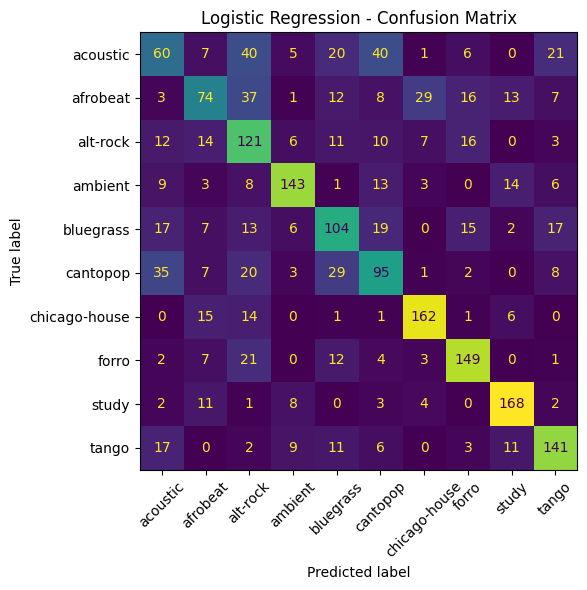

In [17]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

param_grid_lr = {
    "C": [0.01, 0.1, 1, 10],
    "penalty": ["l2"],
    "solver": ["lbfgs"],
    "class_weight": [None, "balanced"],
    "max_iter": [3000]
}

grid_lr = GridSearchCV(
    estimator=LogisticRegression(random_state=0),
    param_grid=param_grid_lr,
    cv=5,
    scoring="accuracy",
    n_jobs=1,
    verbose=1
)

grid_lr.fit(X_train_scaled, y_train)

lr_model = grid_lr.best_estimator_
lr_preds = lr_model.predict(X_test_scaled)
lr_acc = accuracy_score(y_test, lr_preds)

print("Logistic Regression best params:", grid_lr.best_params_)
print("Logistic Regression best CV accuracy: {:.4f}".format(grid_lr.best_score_))
print("Logistic Regression test accuracy: {:.4f}".format(lr_acc))
print(classification_report(y_test, lr_preds, target_names=le.classes_))

cm = confusion_matrix(y_test, lr_preds)
fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(ax=ax, colorbar=False, xticks_rotation=45, values_format="d")
ax.set_title("Logistic Regression - Confusion Matrix")
plt.tight_layout()
plt.show()

Logistic Regression GridSearchCV tuned the model’s hyperparameters and selected the best combination as C = 10, penalty = l2, solver = lbfgs, class weight = None, and max iterations = 3000. The best cross-validation score during tuning was 62.31%, and the model achieved a test accuracy of 60.91%. Logistic Regression performed reasonably well on genres such as study, chicago-house, ambient, and forro, but was weaker on acoustic and afrobeat. Overall, the model captured general genre patterns, but it performed worse than Random Forest, suggesting that the relationships between audio features and genres are not fully linear.

### Cross Validation

In [18]:
from sklearn.model_selection import cross_val_score, StratifiedKFold

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)

rf_cv_scores = cross_val_score(
    rf_model,
    X_train_scaled,
    y_train,
    cv=cv,
    scoring="accuracy",
    n_jobs=-1
)

lr_cv_scores = cross_val_score(
    lr_model,
    X_train_scaled,
    y_train,
    cv=cv,
    scoring="accuracy",
    n_jobs=1
)

print("Random Forest CV scores:", rf_cv_scores)
print("Random Forest CV Accuracy: {:.4f} ± {:.4f}".format(rf_cv_scores.mean(), rf_cv_scores.std()))
print()
print("Logistic Regression CV scores:", lr_cv_scores)
print("Logistic Regression CV Accuracy: {:.4f} ± {:.4f}".format(lr_cv_scores.mean(), lr_cv_scores.std()))

Random Forest CV scores: [0.7146433  0.71214018 0.71339174 0.67709637 0.71884784]
Random Forest CV Accuracy: 0.7072 ± 0.0152

Logistic Regression CV scores: [0.62640801 0.61702128 0.6126408  0.62578223 0.63055729]
Logistic Regression CV Accuracy: 0.6225 ± 0.0066


Cross-validation was used to evaluate how consistently each model performed across different folds of the training data. Random Forest achieved an average cross-validation accuracy of 70.72% with a standard deviation of 0.0152, while Logistic Regression achieved an average cross-validation accuracy of 62.25% with a standard deviation of 0.0066. This shows that Random Forest performed better overall, while Logistic Regression was slightly more consistent across folds because it had lower variation. Overall, Random Forest remained the stronger model since it achieved a clearly higher average accuracy during cross-validation.

# Learning Curves

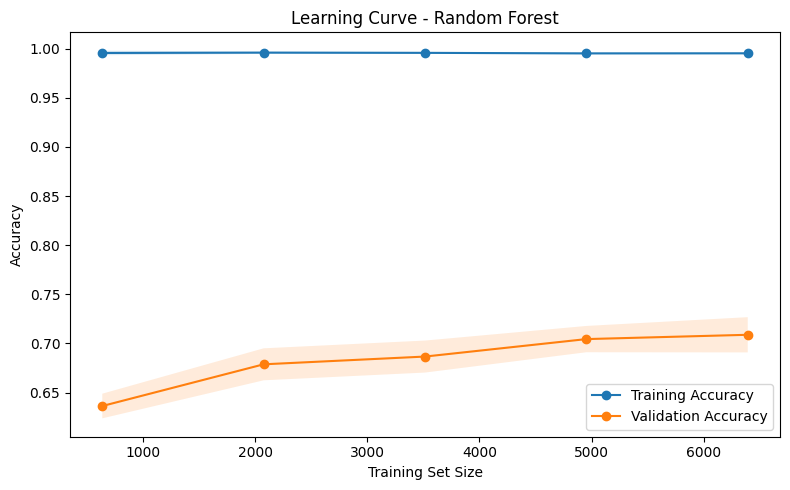

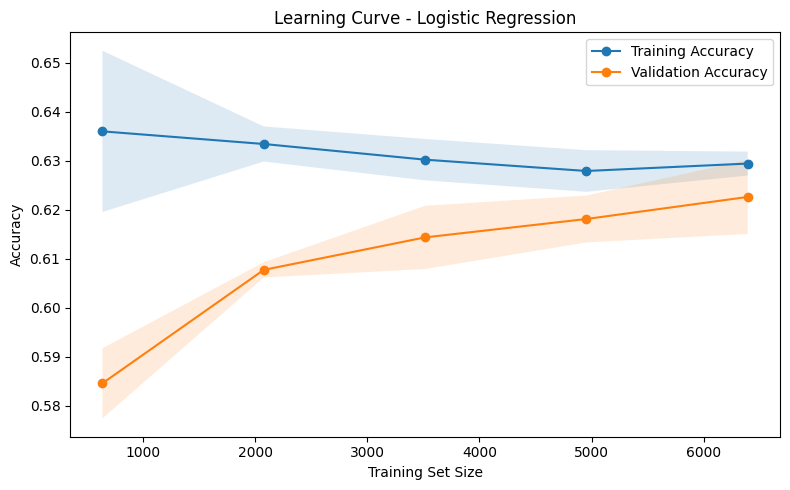

In [19]:
from sklearn.model_selection import learning_curve, StratifiedKFold
import numpy as np
import matplotlib.pyplot as plt

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)

def plot_learning_curve(model, X_data, y_data, title, n_jobs_value):
    train_sizes, train_scores, val_scores = learning_curve(
        estimator=model,
        X=X_data,
        y=y_data,
        cv=cv,
        scoring="accuracy",
        n_jobs=n_jobs_value,
        train_sizes=np.linspace(0.1, 1.0, 5),
        shuffle=True,
        random_state=0
    )

    train_mean = train_scores.mean(axis=1)
    train_std = train_scores.std(axis=1)
    val_mean = val_scores.mean(axis=1)
    val_std = val_scores.std(axis=1)

    plt.figure(figsize=(8, 5))
    plt.plot(train_sizes, train_mean, marker="o", label="Training Accuracy")
    plt.plot(train_sizes, val_mean, marker="o", label="Validation Accuracy")
    plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.15)
    plt.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.15)
    plt.title(title)
    plt.xlabel("Training Set Size")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_learning_curve(
    rf_model,
    X_train_scaled,
    y_train,
    "Learning Curve - Random Forest",
    -1
)

plot_learning_curve(
    lr_model,
    X_train_scaled,
    y_train,
    "Learning Curve - Logistic Regression",
    1
)

# Model Comparison
Among the two models, Random Forest performed better overall than Logistic Regression on the top 10 genre classification task. Random Forest achieved a cross-validation accuracy of 70.72% and a test accuracy of 70.77%, while Logistic Regression achieved a cross-validation accuracy of 62.25% and a test accuracy of 60.91%. This shows that Random Forest was more effective at capturing the relationships between Spotify audio features and genre labels. The learning curves also support this result: Random Forest had higher validation accuracy across training sizes, although its training accuracy stayed near 100%, indicating some overfitting. In contrast, Logistic Regression had lower but more closely aligned training and validation curves, suggesting more stable generalization but weaker predictive power. Overall, Random Forest was the stronger model because it produced higher accuracy and better genre separation, while Logistic Regression was limited by its simpler linear structure.

# Conclusion

Random Forest wins! This project showed that Spotify audio features can be used to classify music genres with moderate success, though overlap between genres makes the task challenging. Among the four models, Random Forest performed best overall, achieving the highest accuracy and strongest genre separation, while Logistic Regression and Decision Tree showed moderate performance, and k-NN performed the weakest. Overall, the results suggest that tree-based models were the most effective for this dataset, especially because they captured non-linear patterns in the audio features better than the other approaches.

# Resources Used
https://www.geeksforgeeks.org/data-analysis/principal-component-analysis-with-python/
https://www.geeksforgeeks.org/machine-learning/decision-tree-implementation-python/
https://www.geeksforgeeks.org/machine-learning/elbow-method-for-optimal-value-of-k-in-kmeans/
https://medium.com/@moussadoumbia_90919/elbow-method-in-supervised-learning-optimal-k-value-99d425f229e7
https://www.geeksforgeeks.org/machine-learning/how-to-find-the-optimal-value-of-k-in-knn/